In [5]:
import sys
import os

# Get the directory containing the notebook
NOTEBOOK_DIR = os.getcwd()

# Compute project root (go up one level)
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '../..'))

# Add project root to path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [6]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
sys.path

['/opt/homebrew/Cellar/python@3.10/3.10.17/Frameworks/Python.framework/Versions/3.10/lib/python310.zip',
 '/opt/homebrew/Cellar/python@3.10/3.10.17/Frameworks/Python.framework/Versions/3.10/lib/python3.10',
 '/opt/homebrew/Cellar/python@3.10/3.10.17/Frameworks/Python.framework/Versions/3.10/lib/python3.10/lib-dynload',
 '',
 '/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/scanpy_umap/lib/python3.10/site-packages',
 '/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/CellUntangler',
 '/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/CellUntangler/notebooks']

In [9]:
adata = sc.read_h5ad("../../../../data/brca/adata_inferploidy_example.h5ad")

In [10]:
adata

AnnData object with n_obs × n_vars = 33742 × 22585
    obs: 'Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity', 'Gender', 'geo_no', 'subtype', 'subtype_detail', 'tissue', 'condition', 'sample', 'sample_ext', 'celltype_major', 'celltype_minor', 'celltype_subset', 'cnv_ref_ind', 'ploidy_score', 'ploidy_dec', 'ploidy_init_group', 'condition_for_deg', 'sample_ext_for_deg', 'celltype_for_deg', 'celltype_for_cci', 'tumor_origin_ind', 'iploidy_score', 'iploidy_dec', 'iploidy_init_group'
    var: 'variable_genes', 'chr', 'spot_no', 'cytogenetic_band', 'chromosome', 'start', 'end', 'gene_id', 'gene_name'
    uns: 'CCI', 'CCI_sample', 'Celltype_marker_DB', 'DEG', 'DEG_grouping_vars', 'DEG_stat', 'DEG_vs_ref', 'DEG_vs_ref_stat', 'GSA_down', 'GSA_up', 'GSA_vs_ref_down', 'GSA_vs_ref_up', 'GSEA', 'GSEA_vs_ref', 'HiCAT_summary', 'Pathways_DB', 'analysis_parameters', 'celltype_major_colors', 'cnv', 'cnv_neighbors', 'cnv_neighbors_info', 'condition_colors', 'gene_to_band_map', 'infe

In [11]:
adata = adata[adata.obs["condition"] == "HER2+"]

In [12]:
adata

View of AnnData object with n_obs × n_vars = 7500 × 22585
    obs: 'Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity', 'Gender', 'geo_no', 'subtype', 'subtype_detail', 'tissue', 'condition', 'sample', 'sample_ext', 'celltype_major', 'celltype_minor', 'celltype_subset', 'cnv_ref_ind', 'ploidy_score', 'ploidy_dec', 'ploidy_init_group', 'condition_for_deg', 'sample_ext_for_deg', 'celltype_for_deg', 'celltype_for_cci', 'tumor_origin_ind', 'iploidy_score', 'iploidy_dec', 'iploidy_init_group'
    var: 'variable_genes', 'chr', 'spot_no', 'cytogenetic_band', 'chromosome', 'start', 'end', 'gene_id', 'gene_name'
    uns: 'CCI', 'CCI_sample', 'Celltype_marker_DB', 'DEG', 'DEG_grouping_vars', 'DEG_stat', 'DEG_vs_ref', 'DEG_vs_ref_stat', 'GSA_down', 'GSA_up', 'GSA_vs_ref_down', 'GSA_vs_ref_up', 'GSEA', 'GSEA_vs_ref', 'HiCAT_summary', 'Pathways_DB', 'analysis_parameters', 'celltype_major_colors', 'cnv', 'cnv_neighbors', 'cnv_neighbors_info', 'condition_colors', 'gene_to_band_map'

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/scanpy_umap/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


KeyError: 'Could not find key cell_type in .var_names or .obs.columns.'

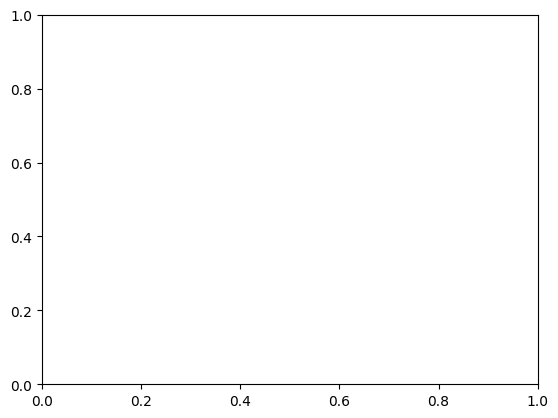

In [13]:
# Use existing PCA
sc.pp.neighbors(
    adata,
    use_rep="X_pca",   # <- key point
    n_neighbors=15,
    n_pcs=50           # adjust if needed
)

sc.tl.umap(adata)

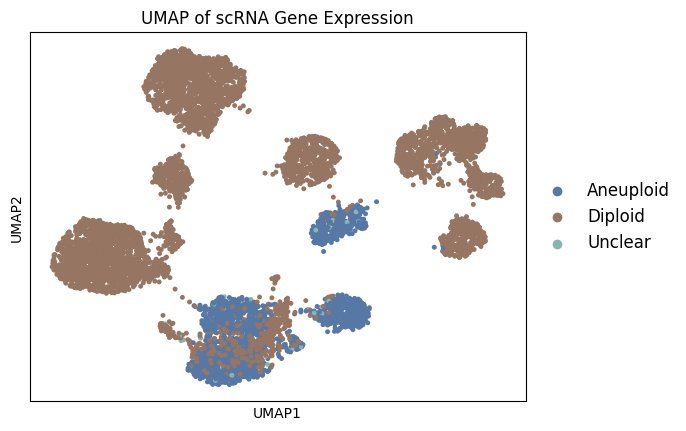

In [21]:
my_palette = {
    "Diploid": "#967662",
    "Aneuploid": "#5778a4",
    "Unclear": "#85b6b2"
}

# Order colors according to the categorical order in adata.obs
colors_ordered = [my_palette[c] for c in adata.obs["ploidy_dec"].cat.categories]

sc.pl.umap(
    adata,
    title="UMAP of scRNA Gene Expression",
    color="ploidy_dec",
    palette=colors_ordered,
    size=50,
    legend_loc="right margin",   # or 'on data', 'lower right', etc.
    legend_fontsize=12
)
